Aim: To verify the possibility of PAPR by addition of pilot-zero

In [1]:
import numpy as np
import itertools
import matplotlib.pyplot as plt
from BMOCZ import BMOCZTransmitter

In [2]:
K = 10

tx = BMOCZTransmitter(K)

PAPR_PZ = {}; PAPR = {}; 
PAPR_DIFF = {};     # without pilot-zero - with pilo-zero

powers_of_two = 2 ** np.arange(K)[::-1]

In [4]:
for bits in itertools.product([0,1], repeat=K):
    msg = np.array(bits)
    sig_NoPZ = tx.coeffCon(msg)
    sig_PZ = tx.coeffConSinglePZ(msg, [1, 1j, -1j])

    dec_equi = msg.dot(powers_of_two)
    papr_nopz = tx.PAPR(sig_NoPZ)
    papr_pz = tx.PAPR(sig_PZ)

    PAPR[dec_equi] = papr_nopz
    PAPR_PZ[dec_equi] = papr_pz
    PAPR_DIFF[dec_equi] = papr_nopz - papr_pz

In [5]:
papr_max = max(PAPR.values())
papr_pz_max = max(PAPR_PZ.values())
perReduction = ( papr_max - papr_pz_max ) / papr_max
print(f"Maximum value of PAPR without zero-pilot: {papr_max}")
print(f"Maximum value of PAPR with zero-pilot: {papr_pz_max}")
print(f"Percentage Reduction with Pilot-Zero compared to BMOCZ: {perReduction * 100}")

Maximum value of PAPR without zero-pilot: 10.302581880620135
Maximum value of PAPR with zero-pilot: 5.956173947428804
Percentage Reduction with Pilot-Zero compared to BMOCZ: 42.18756020146002


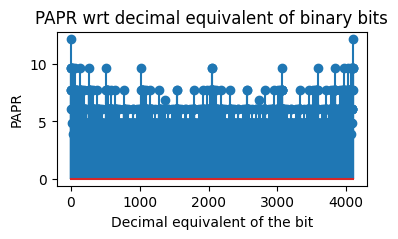

In [28]:
plt.figure(1, figsize=(4,2))
plt.stem(PAPR.keys(), PAPR.values())
plt.xlabel("Decimal equivalent of the bit")
plt.ylabel("PAPR")
plt.title("PAPR wrt decimal equivalent of binary bits")
plt.show()

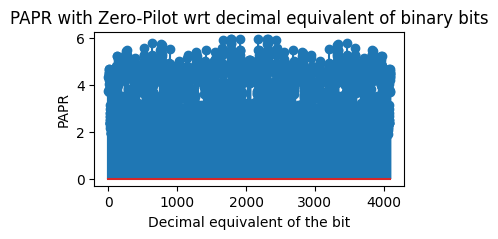

In [29]:
plt.figure(2, figsize=(4,2))
plt.stem(PAPR_PZ.keys(), PAPR_PZ.values())
plt.xlabel("Decimal equivalent of the bit")
plt.ylabel("PAPR")
plt.title("PAPR with Zero-Pilot wrt decimal equivalent of binary bits")
plt.show()

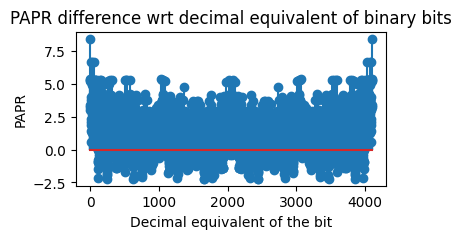

In [30]:
plt.figure(1, figsize=(4,2))
plt.stem(PAPR_DIFF.keys(), PAPR_DIFF.values())
plt.xlabel("Decimal equivalent of the bit")
plt.ylabel("PAPR")
plt.title("PAPR difference wrt decimal equivalent of binary bits")
plt.show()

In [6]:
K = np.arange(1, 10, 1)
Rzm = [-1]
paprReduction = {}; PAPR = {}; PAPR_PZ = {}

In [7]:
for k in K:
    papr_max, papr_pz_max = 0, 0
    tx = BMOCZTransmitter(k)
    for bits in itertools.product([0,1], repeat=k):
        msg = np.array(bits)

        sig_NoPZ = tx.coeffCon(msg)
        sig_PZ = tx.coeffConSinglePZ(msg, Rzm)

        papr_nopz = tx.PAPR(sig_NoPZ)
        papr_pz = tx.PAPR(sig_PZ)

        papr_max = papr_nopz if papr_nopz > papr_max else papr_max
        papr_pz_max = papr_pz if papr_pz > papr_pz_max else papr_pz_max
    PAPR[k] = papr_max
    PAPR_PZ[k] = papr_pz_max
    paprReduction[k] = ( papr_max - papr_pz_max ) * 100 / papr_max
    print(f"Block-Length: {k} done.")

Block-Length: 1 done.
Block-Length: 2 done.
Block-Length: 3 done.
Block-Length: 4 done.
Block-Length: 5 done.
Block-Length: 6 done.
Block-Length: 7 done.
Block-Length: 8 done.
Block-Length: 9 done.


In [8]:
for k in PAPR.keys():
    print(f"Pilot-Zeros at {Rzm}, Block-Length: {k} - PAPR: {PAPR[k]}, PAPR_PZ: {PAPR_PZ[k]}, % PAPR Reduction: {paprReduction[k]}")

Pilot-Zeros at [-1], Block-Length: 1 - PAPR: 1.0, PAPR_PZ: 1.5, % PAPR Reduction: -50.0
Pilot-Zeros at [-1], Block-Length: 2 - PAPR: 2.4000000000000004, PAPR_PZ: 2.331370849898476, % PAPR Reduction: 2.8595479208968393
Pilot-Zeros at [-1], Block-Length: 3 - PAPR: 3.4664956083847422, PAPR_PZ: 2.3637917776767554, % PAPR Reduction: 31.810333988041766
Pilot-Zeros at [-1], Block-Length: 4 - PAPR: 4.473276176271522, PAPR_PZ: 3.7344966797259294, % PAPR Reduction: 16.515400959691377
Pilot-Zeros at [-1], Block-Length: 5 - PAPR: 5.459048721731163, PAPR_PZ: 3.955736196458833, % PAPR Reduction: 27.537994289884303
Pilot-Zeros at [-1], Block-Length: 6 - PAPR: 6.4350567465321555, PAPR_PZ: 4.861625918440732, % PAPR Reduction: 24.450923901165957
Pilot-Zeros at [-1], Block-Length: 7 - PAPR: 7.405747113158985, PAPR_PZ: 5.53559364969338, % PAPR Reduction: 25.252731897131643
Pilot-Zeros at [-1], Block-Length: 8 - PAPR: 8.373226311234186, PAPR_PZ: 6.01666865434478, % PAPR Reduction: 28.14396230671158
Pilot-Z